In [4]:
# =============================================================================
# Imports (EDA + Preprocessing Only)
# =============================================================================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import unidecode
from sklearn.feature_extraction.text import CountVectorizer
from scipy.stats import skew, kurtosis

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [5]:
# =============================================================================
# Load Raw Dataset
# =============================================================================
WineReview = pd.read_csv("winemag-data-130k-v2.csv")

print("First few rows:")
display(WineReview.head())

print("\nData Structure Information:")
print(WineReview.info())

print("\nSummary Statistics:")
display(WineReview.describe(include='all'))

First few rows:


,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks



Data Structure Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129971 entries, 0 to 129970
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             129971 non-null  int64  
 1   country                129908 non-null  object 
 2   description            129971 non-null  object 
 3   designation            92506 non-null   object 
 4   points                 129971 non-null  int64  
 5   price                  120975 non-null  float64
 6   province               129908 non-null  object 
 7   region_1               108724 non-null  object 
 8   region_2               50511 non-null   object 
 9   taster_name            103727 non-null  object 
 10  taster_twitter_handle  98758 non-null   object 
 11  title                  129971 non-null  object 
 12  variety                129970 non-null  object 
 13  winery                 129971 non-null  object 
dtypes: floa

,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
count,129971.000000,129908,129971,92506,129971.000000,120975.000000,129908,108724,50511,103727,98758,129971,129970,129971
unique,NaN,43,119955,37979,NaN,NaN,425,1229,17,19,15,118840,707,16757
top,NaN,US,"Seductively tart in lemon pith, cranberry and ...",Reserve,NaN,NaN,California,Napa Valley,Central Coast,Roger Voss,@vossroger,Gloria Ferrer NV Sonoma Brut Sparkling (Sonoma...,Pinot Noir,Wines & Winemakers
freq,NaN,54504,3,2009,NaN,NaN,36247,4480,11065,25514,25514,11,13272,222
mean,64985.000000,NaN,NaN,NaN,88.447138,35.363389,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,37519.540256,NaN,NaN,NaN,3.039730,41.022218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,NaN,NaN,NaN,80.000000,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,32492.500000,NaN,NaN,NaN,86.000000,17.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,64985.000000,NaN,NaN,NaN,88.000000,25.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,97477.500000,NaN,NaN,NaN,91.000000,42.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# =============================================================================
# Set Seed for Reproducibility
# =============================================================================

student_id = '4741644011'
first_three = int(student_id[:3])
last_three = int(student_id[-3:])
Randomizer = first_three + last_three

np.random.seed(Randomizer)

print(f"Randomizer seed: {Randomizer}")
print("""
A fixed random seed was set to ensure reproducibility across all stochastic
operations. This guarantees consistent results across runs and supports
auditable, stable analysis.
""")

Randomizer seed: 485

A fixed random seed was set to ensure reproducibility across all stochastic
operations. This guarantees consistent results across runs and supports
auditable, stable analysis.



In [7]:
# =============================================================================
# Renaming Variables to Match R Structure
# =============================================================================

WineReview = WineReview.rename(columns={
    'Unnamed: 0': 'row_id',
    'country': 'country',
    'description': 'description',
    'designation': 'designation',
    'points': 'rating_points',
    'price': 'price',
    'province': 'province',
    'region_1': 'primary_region',
    'region_2': 'secondary_region',
    'taster_name': 'taster_name',
    'taster_twitter_handle': 'taster_twitter',
    'title': 'wine_title',
    'variety': 'variety',
    'winery': 'winery'
})


In [8]:
# =============================================================================
# Missing Data Summary (Before Cleaning)
# =============================================================================

def summarize_NAs(df):
    total_blanks = sum((df.astype(str) == "").sum())
    total_na = df.isna().sum().sum()
    total_cells = df.shape[0] * df.shape[1]
    rows_with_nas = (df.isna().sum(axis=1) > 0).sum()
    cols_with_nas = (df.isna().sum(axis=0) > 0).sum()

    return {
        "n_rows": df.shape[0],
        "n_cols": df.shape[1],
        "total_cells": total_cells,
        "total_blanks": total_blanks,
        "total_na": total_na,
        "pct_na_cells": f"{(total_na / total_cells) * 100:.2f}%",
        "rows_with_nas": rows_with_nas,
        "pct_rows_with_nas": f"{(rows_with_nas / df.shape[0]) * 100:.2f}%",
        "cols_with_nas": cols_with_nas,
        "pct_cols_with_nas": f"{(cols_with_nas / df.shape[1]) * 100:.2f}%"
    }

WineReview_summary = summarize_NAs(WineReview)
WineReview_summary

{'n_rows': 129971,
 'n_cols': 14,
 'total_cells': 1819594,
 'total_blanks': 0,
 'total_na': 204752,
 'pct_na_cells': '11.25%',
 'rows_with_nas': 107584,
 'pct_rows_with_nas': '82.78%',
 'cols_with_nas': 9,
 'pct_cols_with_nas': '64.29%'}

In [9]:
# =============================================================================
# Handle Missing Values EXACTLY like R
# =============================================================================

# Convert all object columns to string
for col in WineReview.select_dtypes(include=['object', 'string']).columns:
    WineReview[col] = WineReview[col].astype(str)

# Define ALL missing patterns R treats as NA
missing_patterns = [
    "", " ", "  ", "\t", "\n", "\r",
    "NA", "N/A", "na", "n/a",
    "NaN", "nan", "NAN",
    "None", "none", "NONE",
    "Null", "null", "NULL",
    "Unknown", "unknown", "UNKNOWN"
]

# Replace exact matches
WineReview = WineReview.replace(missing_patterns, np.nan)

# Replace whitespace-only strings
for col in WineReview.select_dtypes(include=['object', 'string']).columns:
    WineReview[col] = WineReview[col].map(
        lambda x: np.nan if isinstance(x, str) and x.strip() == "" else x
    )

Missingness Summary:
  • Total Missing: 204,752
  • Missing %: 11.25%
  • Observed %: 88.75%


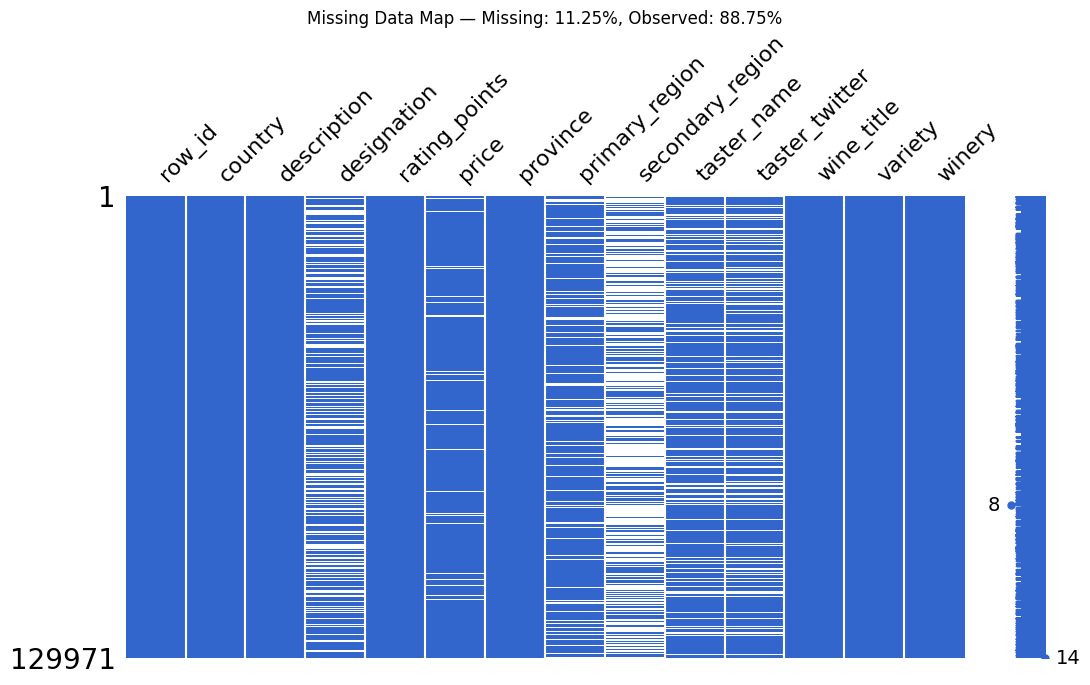

In [10]:
# =============================================================================
# Missingness Summary (matches R)
# =============================================================================

total_cells = WineReview.size
total_missing = WineReview.isna().sum().sum()
pct_missing = (total_missing / total_cells) * 100
pct_observed = 100 - pct_missing

print("Missingness Summary:")
print(f"  • Total Missing: {total_missing:,}")
print(f"  • Missing %: {pct_missing:.2f}%")
print(f"  • Observed %: {pct_observed:.2f}%")

msno.matrix(WineReview, figsize=(12, 6), color=(0.2, 0.4, 0.8))
plt.title(f"Missing Data Map — Missing: {pct_missing:.2f}%, Observed: {pct_observed:.2f}%")
plt.show()

Numeric variables: ['rating_points', 'price']

Outlier Summary Table:


,Variable,Outlier_Count,Outlier_Percent
0,rating_points,52,0.04
1,price,7241,5.57


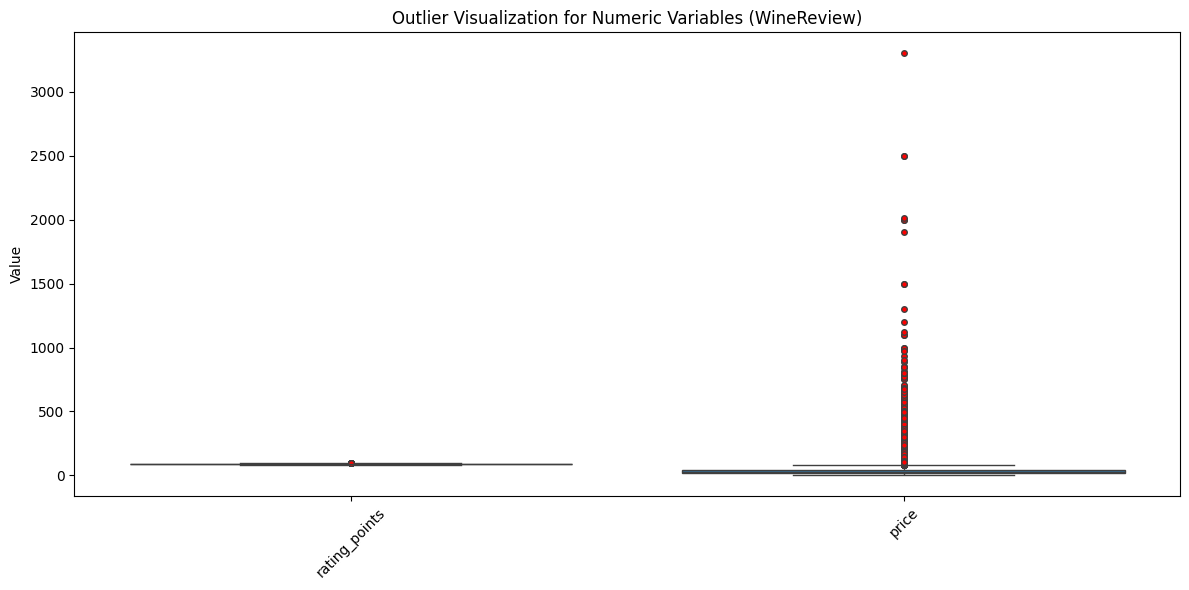

In [11]:
# =============================================================================
# Outlier Detection Using the 1.5×IQR Rule (on cleaned WineReview)
# =============================================================================
numeric_vars = WineReview.select_dtypes(include=['number']).columns.tolist()
numeric_vars = [col for col in numeric_vars if col != 'row_id']
print("Numeric variables:", numeric_vars)

def flag_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return (series < lower) | (series > upper)

# Compute outliers
outlier_flags = {col: flag_outliers(WineReview[col]) for col in numeric_vars}
outlier_counts = {col: flags.sum() for col, flags in outlier_flags.items()}
outlier_percentages = {
    col: round((count / WineReview.shape[0]) * 100, 2)
    for col, count in outlier_counts.items()
}

# Summary table
outlier_summary = pd.DataFrame({
    "Variable": list(outlier_counts.keys()),
    "Outlier_Count": list(outlier_counts.values()),
    "Outlier_Percent": list(outlier_percentages.values())
})

print("\nOutlier Summary Table:")
display(outlier_summary)

# =============================================================================
# Outlier Boxplot Visualization
# =============================================================================

boxplot_data = WineReview[numeric_vars].melt(
    var_name="feature",
    value_name="value"
)

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=boxplot_data,
    x="feature",
    y="value",
    showfliers=True,
    flierprops=dict(marker='o', markersize=4, markerfacecolor='red')
)

plt.title("Outlier Visualization for Numeric Variables (WineReview)")
plt.xlabel("")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [12]:
# =============================================================================
# Log Transformation
# =============================================================================
WineReview["log_price"] = np.log1p(WineReview["price"])

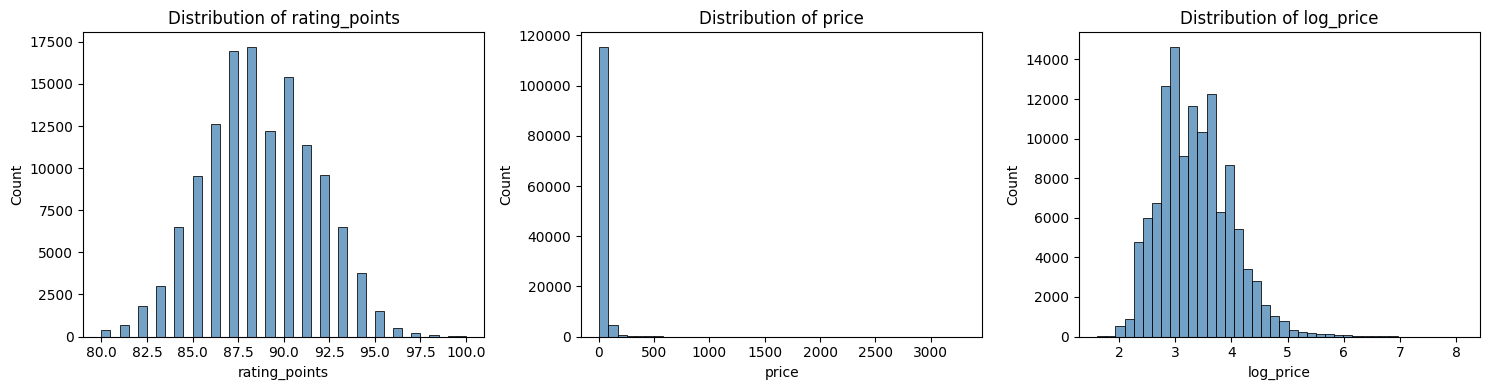

In [13]:
# =============================================================================
# Univariate Numeric
# =============================================================================
numeric_vars = ["rating_points", "price", "log_price"]

plt.figure(figsize=(15, 4))
for i, v in enumerate(numeric_vars, 1):
    plt.subplot(1, 3, i)
    sns.histplot(WineReview[v], bins=40, color="steelblue")
    plt.title(f"Distribution of {v}")
plt.tight_layout()
plt.show()

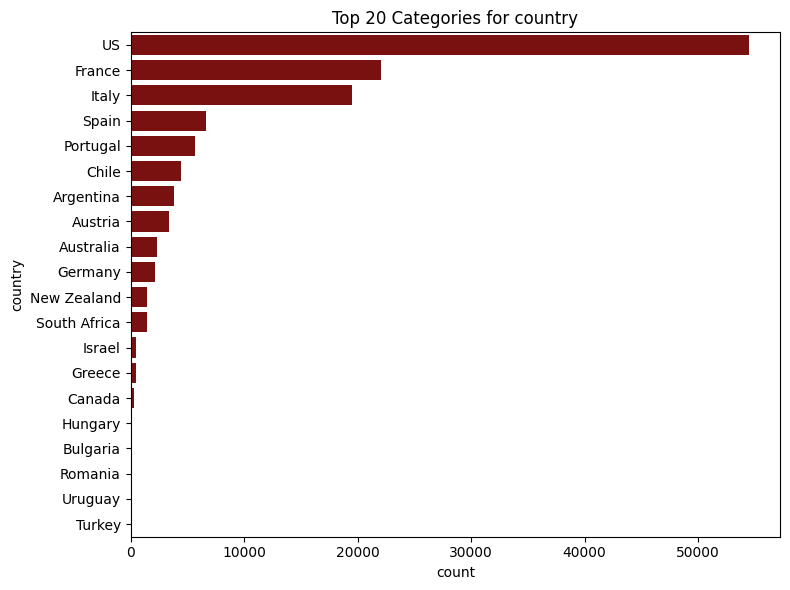

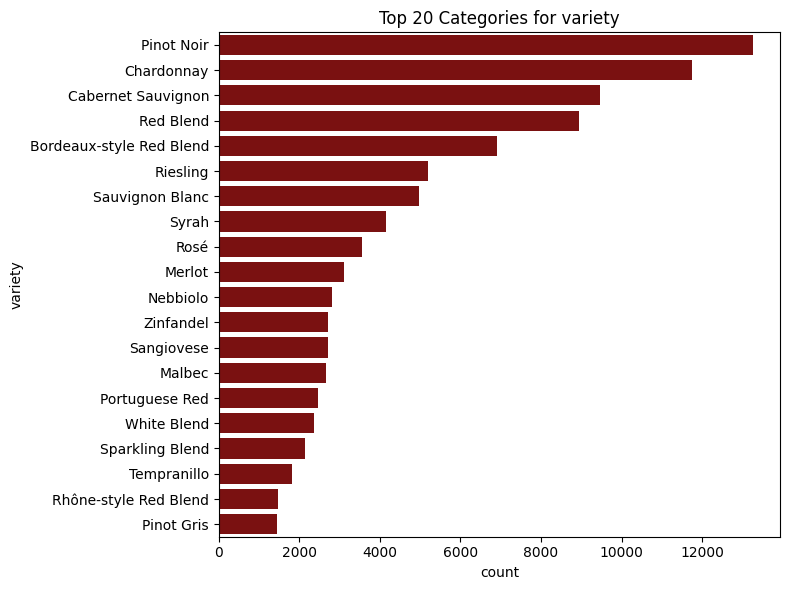

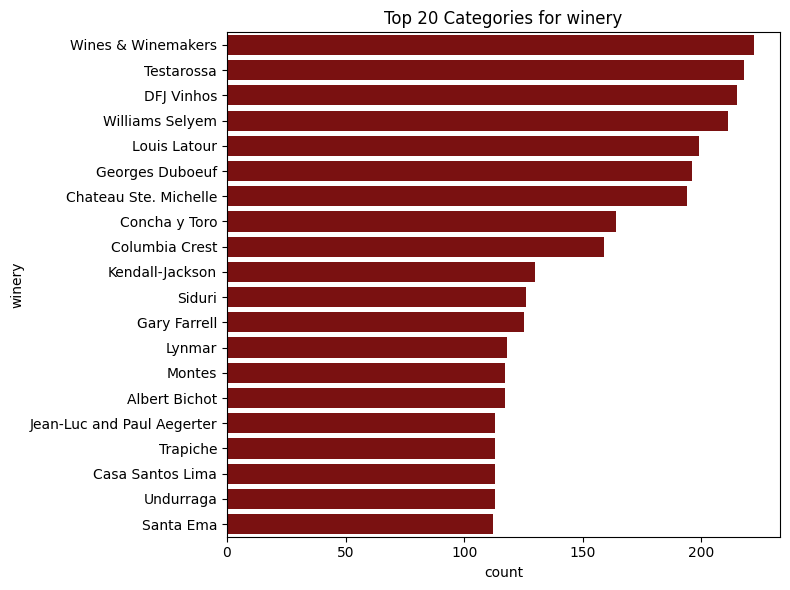

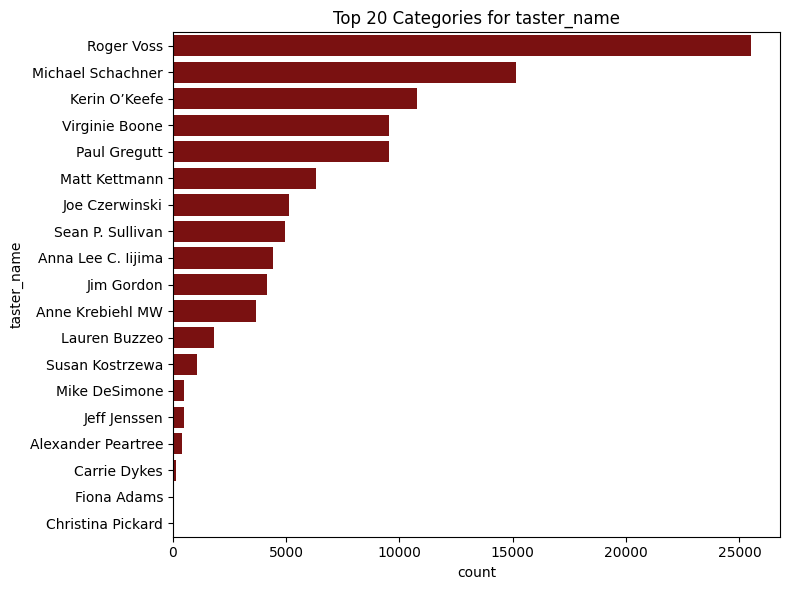

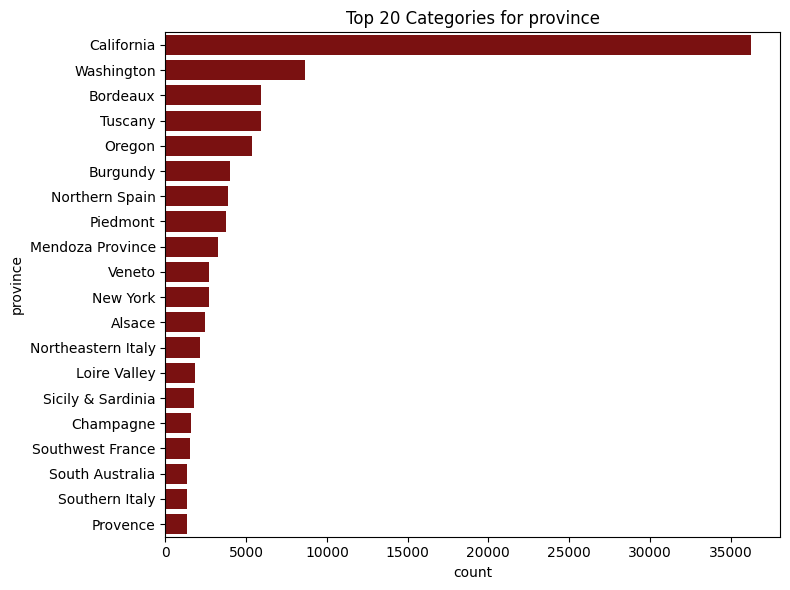

In [14]:
# =============================================================================
# Univariate Categorical
# =============================================================================
cat_vars = ["country", "variety", "winery", "taster_name", "province"]

for v in cat_vars:
    top20 = WineReview[v].value_counts(dropna=False).head(20).reset_index()
    top20.columns = [v, "count"]

    plt.figure(figsize=(8, 6))
    sns.barplot(data=top20, y=v, x="count", color="darkred")
    plt.title(f"Top 20 Categories for {v}")
    plt.tight_layout()
    plt.show()

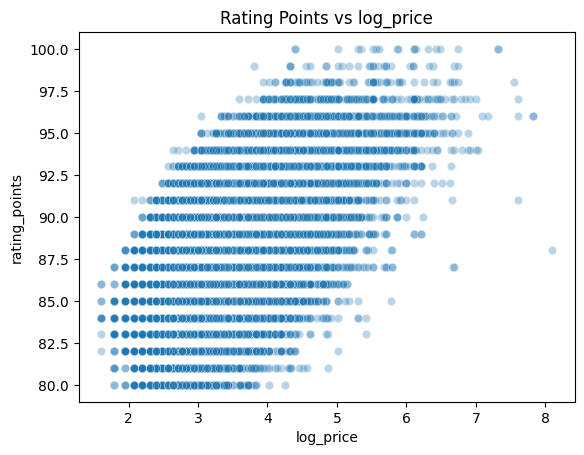

In [15]:
# =============================================================================
# Bivariate Numeric vs Numeric
# =============================================================================
sns.scatterplot(data=WineReview, x="log_price", y="rating_points", alpha=0.3)
plt.title("Rating Points vs log_price")
plt.show()

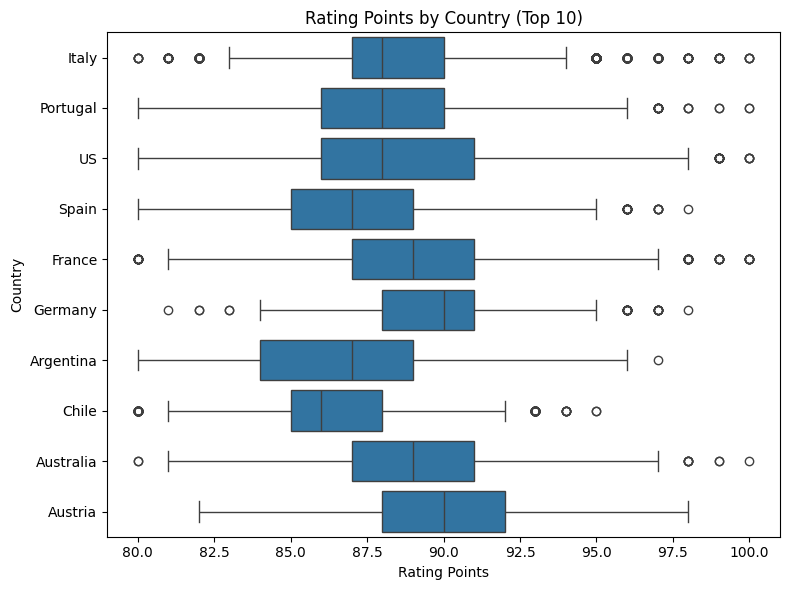

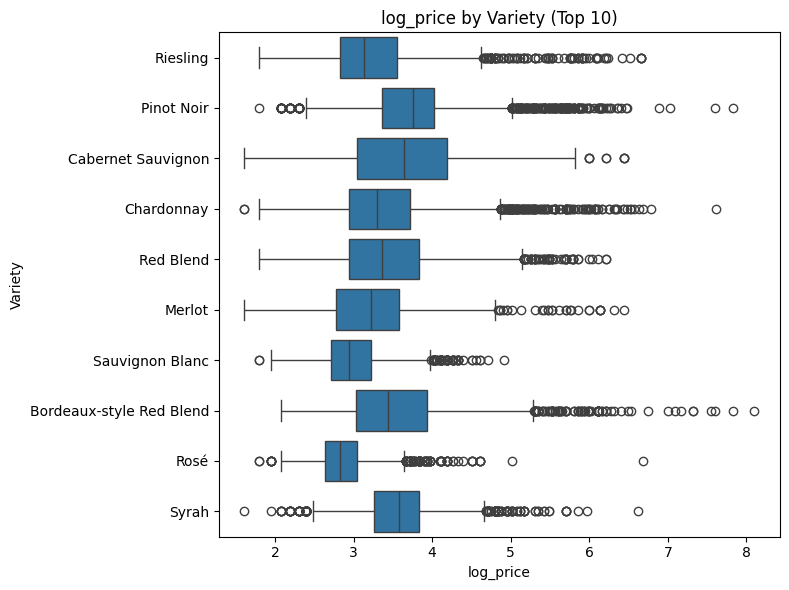

In [16]:
# =============================================================================
# BIVARIATE ANALYSIS — NUMERIC vs CATEGORICAL
# =============================================================================

# -----------------------------
# Top 10 Countries by frequency
# -----------------------------
top_countries = (
    WineReview["country"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=WineReview[WineReview["country"].isin(top_countries)],
    x="rating_points",
    y="country"
)
plt.title("Rating Points by Country (Top 10)")
plt.xlabel("Rating Points")
plt.ylabel("Country")
plt.tight_layout()
plt.show()


# -----------------------------
# Top 10 Varieties by frequency
# -----------------------------
top_varieties = (
    WineReview["variety"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=WineReview[WineReview["variety"].isin(top_varieties)],
    x="log_price",
    y="variety"
)
plt.title("log_price by Variety (Top 10)")
plt.xlabel("log_price")
plt.ylabel("Variety")
plt.tight_layout()
plt.show()

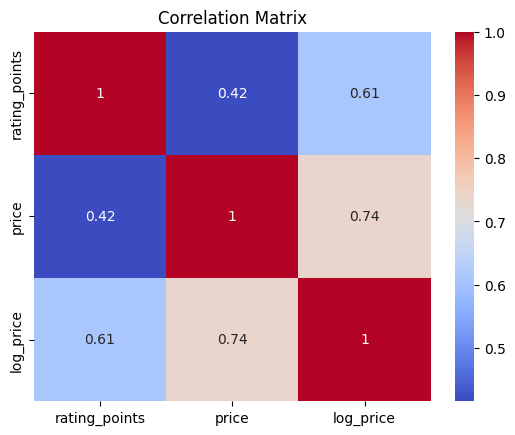

In [17]:
# =============================================================================
# Correlation Matrix
# =============================================================================
num_data = WineReview[["rating_points", "price", "log_price"]].astype(float)
sns.heatmap(num_data.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [18]:
# =============================================================================
# TEXT PREPROCESSING
# =============================================================================

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = unidecode.unidecode(text)
    text = re.sub(r"[^a-z\s]", " ", text)
    tokens = [w for w in text.split() if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

WineReview["clean_text"] = WineReview["description"].apply(preprocess)
# =============================================================================
# TEXT PREPROCESSING — FULL PYTHON EQUIVALENT OF YOUR R PIPELINE
# =============================================================================
!pip install unidecode
import pandas as pd
import numpy as np
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import unidecode

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    if pd.isna(text):
        return ""

    text = text.lower()                                  # lowercase
    text = unidecode.unidecode(text)                     # transliterate UTF-8 → ASCII
    text = re.sub(r'[^a-z\s]', ' ', text)                # remove punctuation & noise
    tokens = text.split()                                # tokenize
    tokens = [w for w in tokens if w not in stop_words]  # remove stopwords
    tokens = [lemmatizer.lemmatize(w) for w in tokens]   # lemmatize
    return " ".join(tokens)                              # rebuild clean text

WineReview["clean_text"] = WineReview["description"].apply(preprocess)

# Preview
print(WineReview[["description", "clean_text"]].head())


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


[nltk_data] Downloading package stopwords to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /home/codespace/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                                         description  \
0  Aromas include tropical fruit, broom, brimston...   
1  This is ripe and fruity, a wine that is smooth...   
2  Tart and snappy, the flavors of lime flesh and...   
3  Pineapple rind, lemon pith and orange blossom ...   
4  Much like the regular bottling from 2012, this...   

                                          clean_text  
0  aroma include tropical fruit broom brimstone d...  
1  ripe fruity wine smooth still structured firm ...  
2  tart snappy flavor lime flesh rind dominate gr...  
3  pineapple rind lemon pith orange blossom start...  
4  much like regular bottling come across rather ...  


In [19]:
# =============================================================================
# SENTIMENT LABELING
# =============================================================================
def label_sentiment(score):
    if score >= 90:
        return "positive"
    elif score >= 85:
        return "neutral"
    else:
        return "negative"

WineReview["sentiment"] = WineReview["rating_points"].apply(label_sentiment)

print("Sentiment Class Balance:")
print(WineReview["sentiment"].value_counts())

Sentiment Class Balance:
sentiment
neutral     68496
positive    49045
negative    12430
Name: count, dtype: int64


In [20]:
# =============================================================================
# UNIGRAMS + BIGRAMS
# =============================================================================

# ---- Unigrams ----
vectorizer_uni = CountVectorizer(max_features=20)
uni_matrix = vectorizer_uni.fit_transform(WineReview["clean_text"])

unigram_df = pd.DataFrame({
    "word": vectorizer_uni.get_feature_names_out(),
    "count": uni_matrix.sum(axis=0).A1
}).sort_values(by="count", ascending=False)

print("\nTop 20 Unigrams:")
display(unigram_df)

# ---- Bigrams ----
vectorizer_bi = CountVectorizer(ngram_range=(2,2), max_features=20)
bi_matrix = vectorizer_bi.fit_transform(WineReview["clean_text"])

bigram_df = pd.DataFrame({
    "bigram": vectorizer_bi.get_feature_names_out(),
    "count": bi_matrix.sum(axis=0).A1
}).sort_values(by="count", ascending=False)

print("\nTop 20 Bigrams:")
display(bigram_df)


Top 20 Unigrams:


,word,count
19,wine,83107
8,flavor,68846
10,fruit,63489
1,aroma,41051
13,palate,38624
7,finish,38582
0,acidity,35003
4,cherry,33583
18,tannin,32978
5,drink,30904



Top 20 Bigrams:


,bigram,count
1,black cherry,8861
7,fruit flavor,7982
8,full bodied,6932
3,black fruit,5608
6,cabernet sauvignon,5259
16,red fruit,4656
13,ready drink,4308
11,palate offer,4256
2,black currant,3778
0,berry fruit,3763


/tmp/ipykernel_174810/290021594.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=WineReview["sentiment"], palette="viridis", ax=axes[0,1])
/tmp/ipykernel_174810/290021594.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=unigram_df, x="count", y="word", palette="magma", ax=axes[1,0])
/tmp/ipykernel_174810/290021594.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bigram_df, x="count", y="bigram", palette="cividis", ax=axes[1,1])


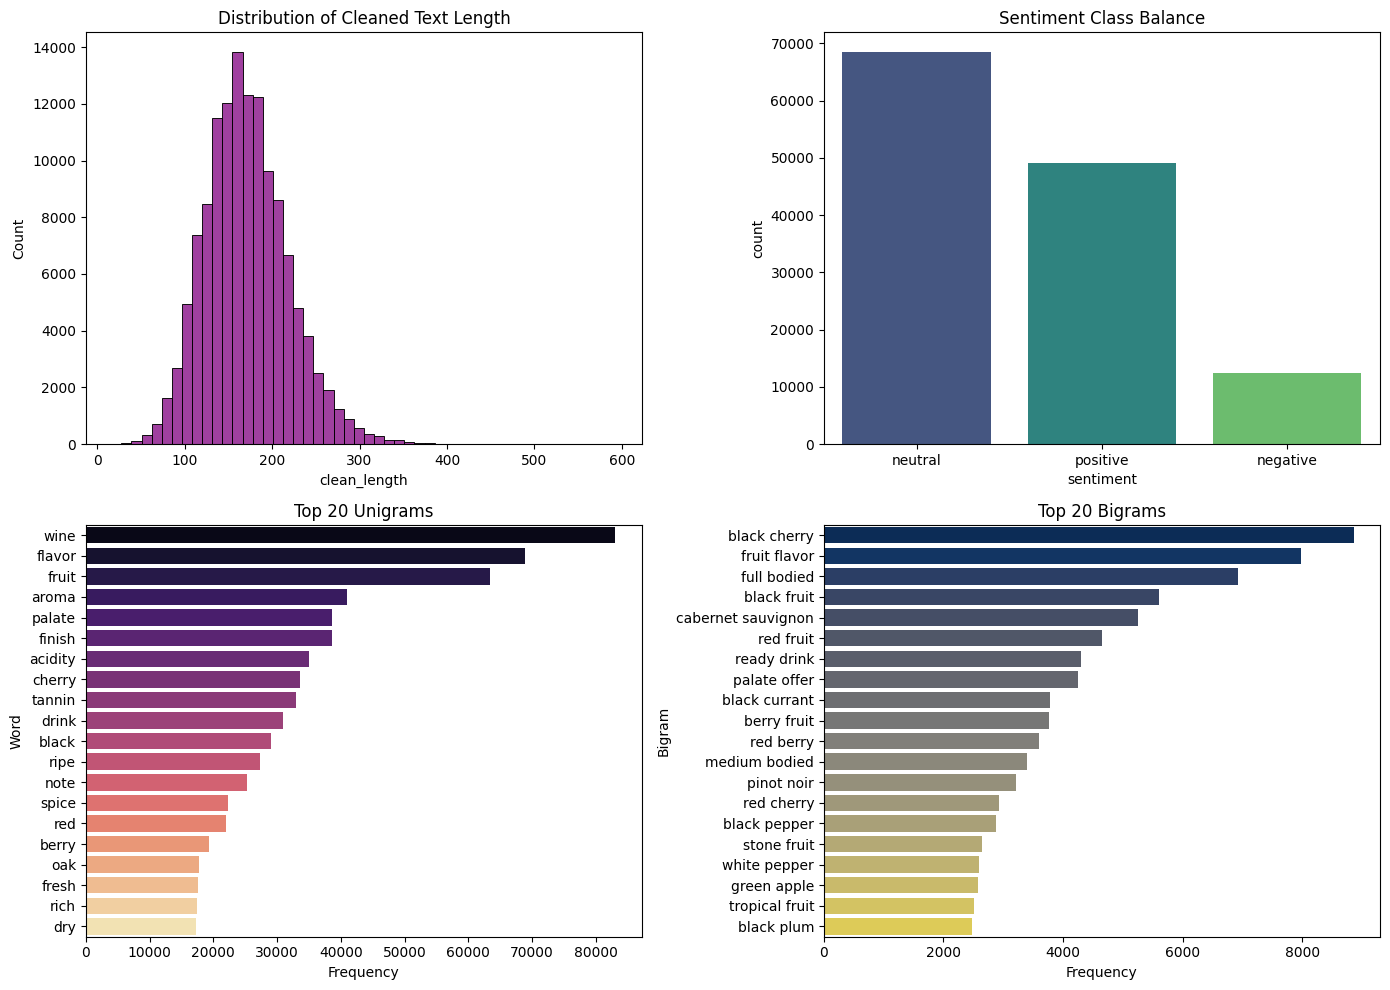


Total tokens: 3255489
Unique vocabulary size: 27855


In [21]:
# =============================================================================
# VISUALIZATIONS + VOCABULARY SIZE
# =============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Clean text length
WineReview["clean_length"] = WineReview["clean_text"].str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ---- 1. Cleaned text length ----
sns.histplot(WineReview["clean_length"], bins=50, color="purple", ax=axes[0,0])
axes[0,0].set_title("Distribution of Cleaned Text Length")

# ---- 2. Sentiment class balance ----
sns.countplot(x=WineReview["sentiment"], palette="viridis", ax=axes[0,1])
axes[0,1].set_title("Sentiment Class Balance")

# ---- 3. Top 20 unigrams ----
sns.barplot(data=unigram_df, x="count", y="word", palette="magma", ax=axes[1,0])
axes[1,0].set_title("Top 20 Unigrams")
axes[1,0].set_xlabel("Frequency")
axes[1,0].set_ylabel("Word")

# ---- 4. Top 20 bigrams ----
sns.barplot(data=bigram_df, x="count", y="bigram", palette="cividis", ax=axes[1,1])
axes[1,1].set_title("Top 20 Bigrams")
axes[1,1].set_xlabel("Frequency")
axes[1,1].set_ylabel("Bigram")

plt.tight_layout()
plt.show()

# ---- Vocabulary Size ----
all_tokens = " ".join(WineReview["clean_text"]).split()
unique_words = set(all_tokens)

print("\nTotal tokens:", len(all_tokens))
print("Unique vocabulary size:", len(unique_words))

In [22]:
# =============================================================================
# CREATE DATASET A (remove rows with ≥20% missing)
# =============================================================================
row_thresh = 0.2 * WineReview.shape[1]
WineReview_A = WineReview[WineReview.isna().sum(axis=1) < row_thresh]

# =============================================================================
# CREATE DATASET B (full dataset)
# =============================================================================
WineReview_B = WineReview.copy()

In [23]:
# =============================================================================
# DESCRIPTIVE STATISTICS + DYNAMIC IMPUTATION
# =============================================================================

DF = WineReview_A.copy()

def calculate_mode(x):
    x = x.dropna()
    return x.mode().iloc[0] if len(x) else np.nan

def calculate_stats(df, columns):
    stats_list = []
    for col in columns:
        x = df[col].dropna()
        if x.empty:
            continue
        stats_list.append({
            "Variable": col,
            "Mean": round(x.mean(), 2),
            "Median": round(x.median(), 2),
            "Mode": round(calculate_mode(x), 2),
            "St.Deviation": round(x.std(), 2),
            "Range": round(x.max() - x.min(), 2),
            "IQR": round(x.quantile(0.75) - x.quantile(0.25), 2),
            "Skewness": round(skew(x, bias=False), 2),
            "Kurtosis": round(kurtosis(x, bias=False), 2)
        })
    return pd.DataFrame(stats_list)

numeric_cols = DF.select_dtypes(include=[np.number]).columns.tolist()
descriptive_stats_A = calculate_stats(DF, numeric_cols)
display(descriptive_stats_A)

,Variable,Mean,Median,Mode,St.Deviation,Range,IQR,Skewness,Kurtosis
0,row_id,65060.92,65162.00,0.00,37529.91,129970.00,65053.00,-0.00,-1.20
1,rating_points,88.48,88.00,88.00,3.04,20.00,5.00,0.03,-0.29
2,price,35.57,25.00,20.00,41.34,3296.00,25.00,17.99,824.11
3,log_price,3.36,3.26,3.04,0.63,6.49,0.87,0.65,0.88
4,clean_length,171.95,168.00,165.00,48.02,578.00,62.00,0.52,0.82


In [24]:
# =============================================================================
# DYNAMIC IMPUTATION FOR WineReview_A
# =============================================================================

skew_info = descriptive_stats_A.set_index("Variable")["Skewness"]

def dynamic_impute_numeric(series, varname):
    skew_val = skew_info.loc[varname]
    return series.fillna(series.median() if abs(skew_val) > 1 else series.mean())

WineReview_A["price"] = dynamic_impute_numeric(WineReview_A["price"], "price")
WineReview_A["log_price"] = dynamic_impute_numeric(WineReview_A["log_price"], "log_price")

def mode_impute(series):
    non_missing = series.dropna()
    return series.fillna(non_missing.mode().iloc[0]) if len(non_missing) else series

WineReview_A["designation"] = mode_impute(WineReview_A["designation"])
WineReview_A["primary_region"] = mode_impute(WineReview_A["primary_region"])

/tmp/ipykernel_174810/3706210885.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  WineReview_A["price"] = dynamic_impute_numeric(WineReview_A["price"], "price")
/tmp/ipykernel_174810/3706210885.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  WineReview_A["log_price"] = dynamic_impute_numeric(WineReview_A["log_price"], "log_price")
/tmp/ipykernel_174810/3706210885.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer

In [25]:
# =============================================================================
# MISSING DATA PROFILE AFTER IMPUTATION (WineReview_A)
# =============================================================================

# Count NA values per column
na_count_after = WineReview_A.isna().sum()

# Count blank strings per column (should be zero after imputation)
blank_count_after = (WineReview_A == "").sum()

# Percent missing per column
missing_pct_after = ((na_count_after + blank_count_after) / len(WineReview_A)) * 100

# Build profile table
missing_profile_after = pd.DataFrame({
    "Variable": WineReview_A.columns,
    "NA_Count": na_count_after.values,
    "Blank_Count": blank_count_after.values,
    "Missing_Pct": missing_pct_after.round(2).values
})

print("\nMissing Data Profile AFTER Imputation (WineReview_A):")
print(missing_profile_after)


Missing Data Profile AFTER Imputation (WineReview_A):
            Variable  NA_Count  Blank_Count  Missing_Pct
0             row_id         0            0         0.00
1            country         0            0         0.00
2        description         0            0         0.00
3        designation         0            0         0.00
4      rating_points         0            0         0.00
5              price         0            0         0.00
6           province         0            0         0.00
7     primary_region         0            0         0.00
8   secondary_region     71077            0        58.46
9        taster_name     21690            0        17.84
10    taster_twitter     26440            0        21.75
11        wine_title         0            0         0.00
12           variety         0            0         0.00
13            winery         0            0         0.00
14         log_price         0            0         0.00
15        clean_text         0   

In [26]:
# =============================================================================
# FEATURE ENGINEERING
# =============================================================================

def feature_engineer(df):
    df = df.copy()
    df["clean_text"] = df["clean_text"].fillna("").astype(str)
    df["word_count"] = df["clean_text"].apply(lambda x: len(x.split()))
    df["char_count"] = df["clean_text"].apply(len)
    df["avg_word_length"] = df["char_count"] / df["word_count"].replace(0, np.nan)
    df["price_per_point"] = df["price"] / df["rating_points"]
    df["price_z"] = (df["price"] - df["price"].mean()) / df["price"].std()
    df["primary_region"] = df["primary_region"].fillna("").astype(str)
    df["region_name_length"] = df["primary_region"].apply(len)
    df["region_token_count"] = df["primary_region"].apply(lambda x: len(x.split()))
    df["designation"] = df["designation"].fillna("").astype(str)
    df["has_designation"] = df["designation"].apply(lambda x: 0 if x == "" else 1)
    df["designation_length"] = df["designation"].apply(len)
    df["has_taster"] = df["taster_name"].apply(lambda x: 0 if pd.isna(x) else 1)
    return df

WineReview_A = feature_engineer(WineReview_A)
WineReview_B = feature_engineer(WineReview_B)

In [27]:
# =============================================================================
# SAVE CLEANED DATASETS
# =============================================================================

WineReview_A.to_csv("data/WineReview_A_cleaned.csv", index=False)
WineReview_B.to_csv("data/WineReview_B_cleaned.csv", index=False)

print("Cleaned datasets saved successfully.")

Cleaned datasets saved successfully.
